<a href="https://colab.research.google.com/github/sujeet-banerjee/colab-genai-scratch/blob/sujeet-banerjee-patch-1/Linear_Regression_Pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Load data

In [ ]:
import pandas as pd

#pd.read_csv('/content/sample_data/california_housing_train.csv')
data = pd.read_csv(
    'https://raw.githubusercontent.com/sujeet-banerjee/colab-genai-scratch/bce40a46ce05916d6112895982a13c24aff5e95d/sample_data/linear_regression_test.csv'
       )


print(data.head())
print()
print("Dataframe shape:", data.shape)
rows = data.shape[0]
print("Rows: ", rows)

# ALL the F***-ing attribs and meth0ds!
# print(data.keys)
# print(data.columns)
# print(data.to_records)
# print(data.values)


num_features = 3
num_out = 2


In [ ]:
from numpy import shape
import torch

print("Targets: \n", data[['Target_1', 'Target_2']].head())

# # Column vectors as tensors!
Y_true = torch.tensor(
    data[['Target_1', 'Target_2']].
    values.reshape((rows, num_out)))

#print(f"True valyes: Y_true={Y_true}\n")

X_data = data[['Feature_1', 'Feature_2', 'Feature_3']]
print("\nFeature Set: \n", X_data.head())

X = torch.tensor(
    X_data.values.reshape(rows, num_features),
    requires_grad=True)



In [ ]:
W = torch.randn(
    size=(num_features, num_out),
    dtype=torch.float64,
    requires_grad=True)
b = torch.randn(
    num_out, requires_grad=True
    )

print(f"W=\n{W}")
print(f"b=\n{b}")

# print("There is no .head for tensors!!!")
# print(b)
# print((X @ W)[[0,1,2,3]])
# print((X @ W + b)[[0,1,2,3]])


In [ ]:
import numpy as np

# DONT make the lraning rate high. Keep it 0.01 max
itr, lrn = 10000, 0.01

for epoch in range(itr):
  Y_hat = X @ W + b

  loss = torch.sqrt(torch.mean((Y_true-Y_hat)**2))
  #loss = ((Y_true - Y_hat)**2).mean()
  loss.backward(retain_graph=True, create_graph=True
                )

  # if epoch % 10 == 0:
  #   print(f"\n\nEpoch={epoch} ; \nW.grad=\n{W.grad}, \nb.grad=\n{b.grad} |  \nLoss = {loss}")
  #   print(f">>>>> W=\n{W}, \n>>>>> b=\n{b} ")

  with torch.no_grad():
    # some silly error will misguide you, if you forgot requires_grad = True
    # Python mean, no clear error message! So, you keep breakin your head!
    W -= lrn * W.grad
    b -= lrn * b.grad

    # If you move this block out of 'no_grad'
    # RuntimeError: a leaf Variable that requires grad
    # is being used in an in-place operation.
    # That USUALLY is the most ***King error one would face...
    # That is, making the parameters W AN B both ZEORRRRO, instead of their grads!
    # W.zero_()
    # b.zero_()

    # MAKE THE GRADS ZERO... NOT THE WEIGHTS AND BIASES!
    W.grad.zero_()
    b.grad.zero_()



In [ ]:
rmse_final = ((Y_hat.detach() - Y_true.detach())**2).mean().sqrt()
print(f"\n\nEpoch={epoch} ; \n\n**Feature coefficients: \n W=\n{W}, \n\n**Y-Intercepts \n b=\n{b} ")
print("RMSE FINAL= ", rmse_final)

#print(f"\n\nPredicted (Target_1): ", Y_hat[:,0].reshape(rows, 1))

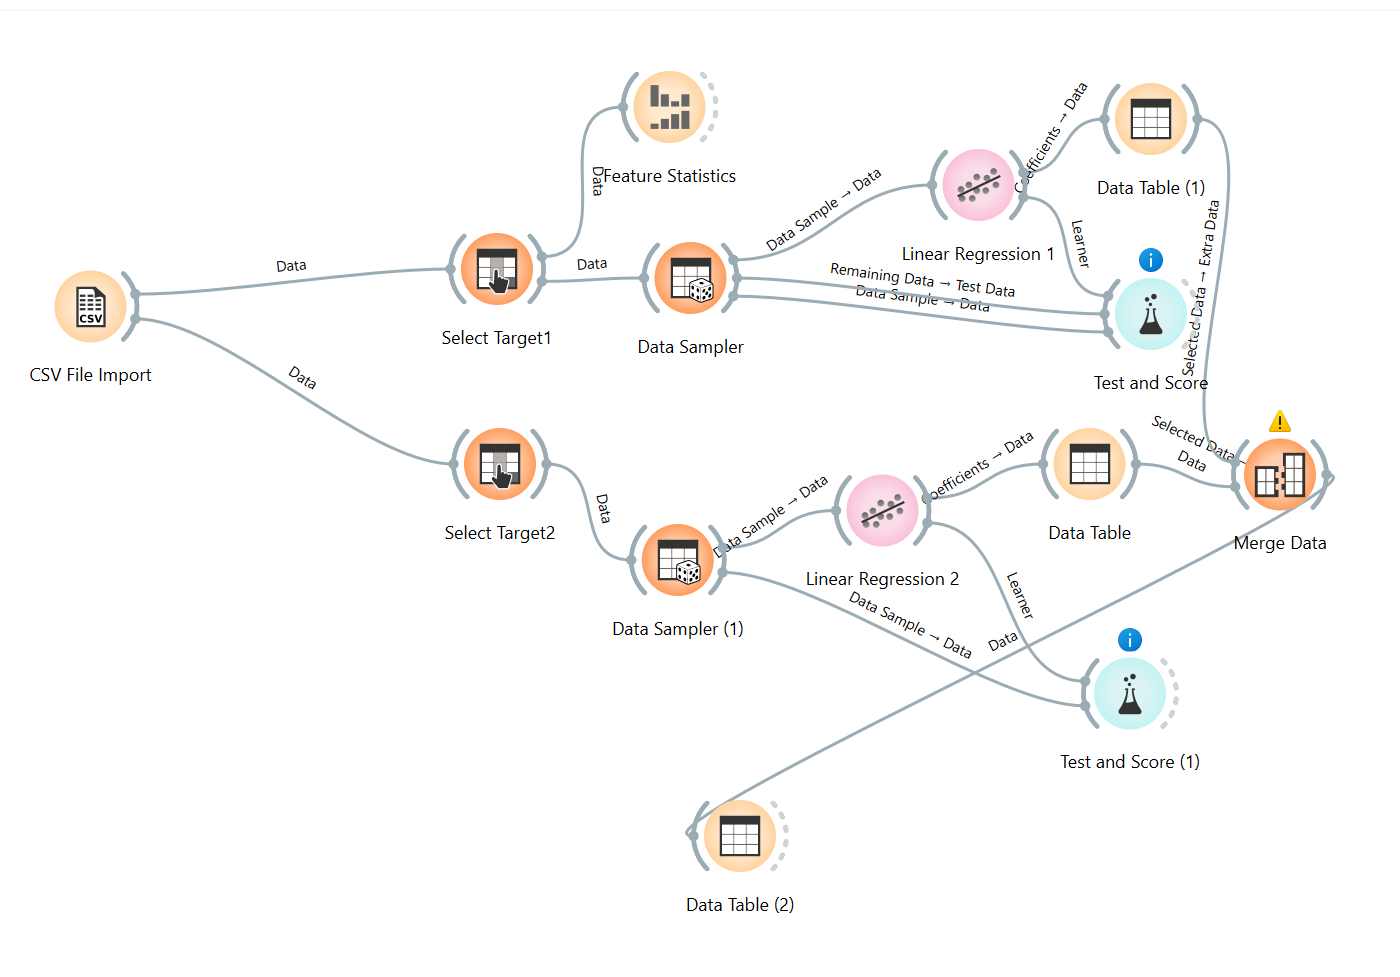

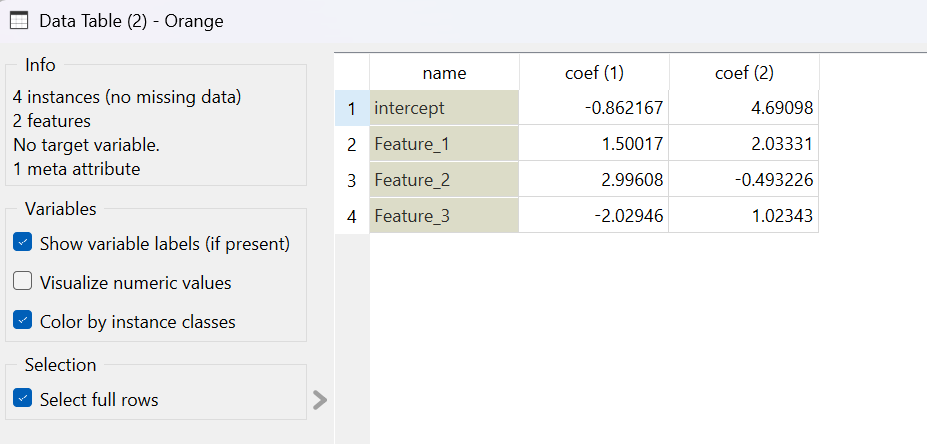

## Data visualization Scatter-Plot

(14, 14)


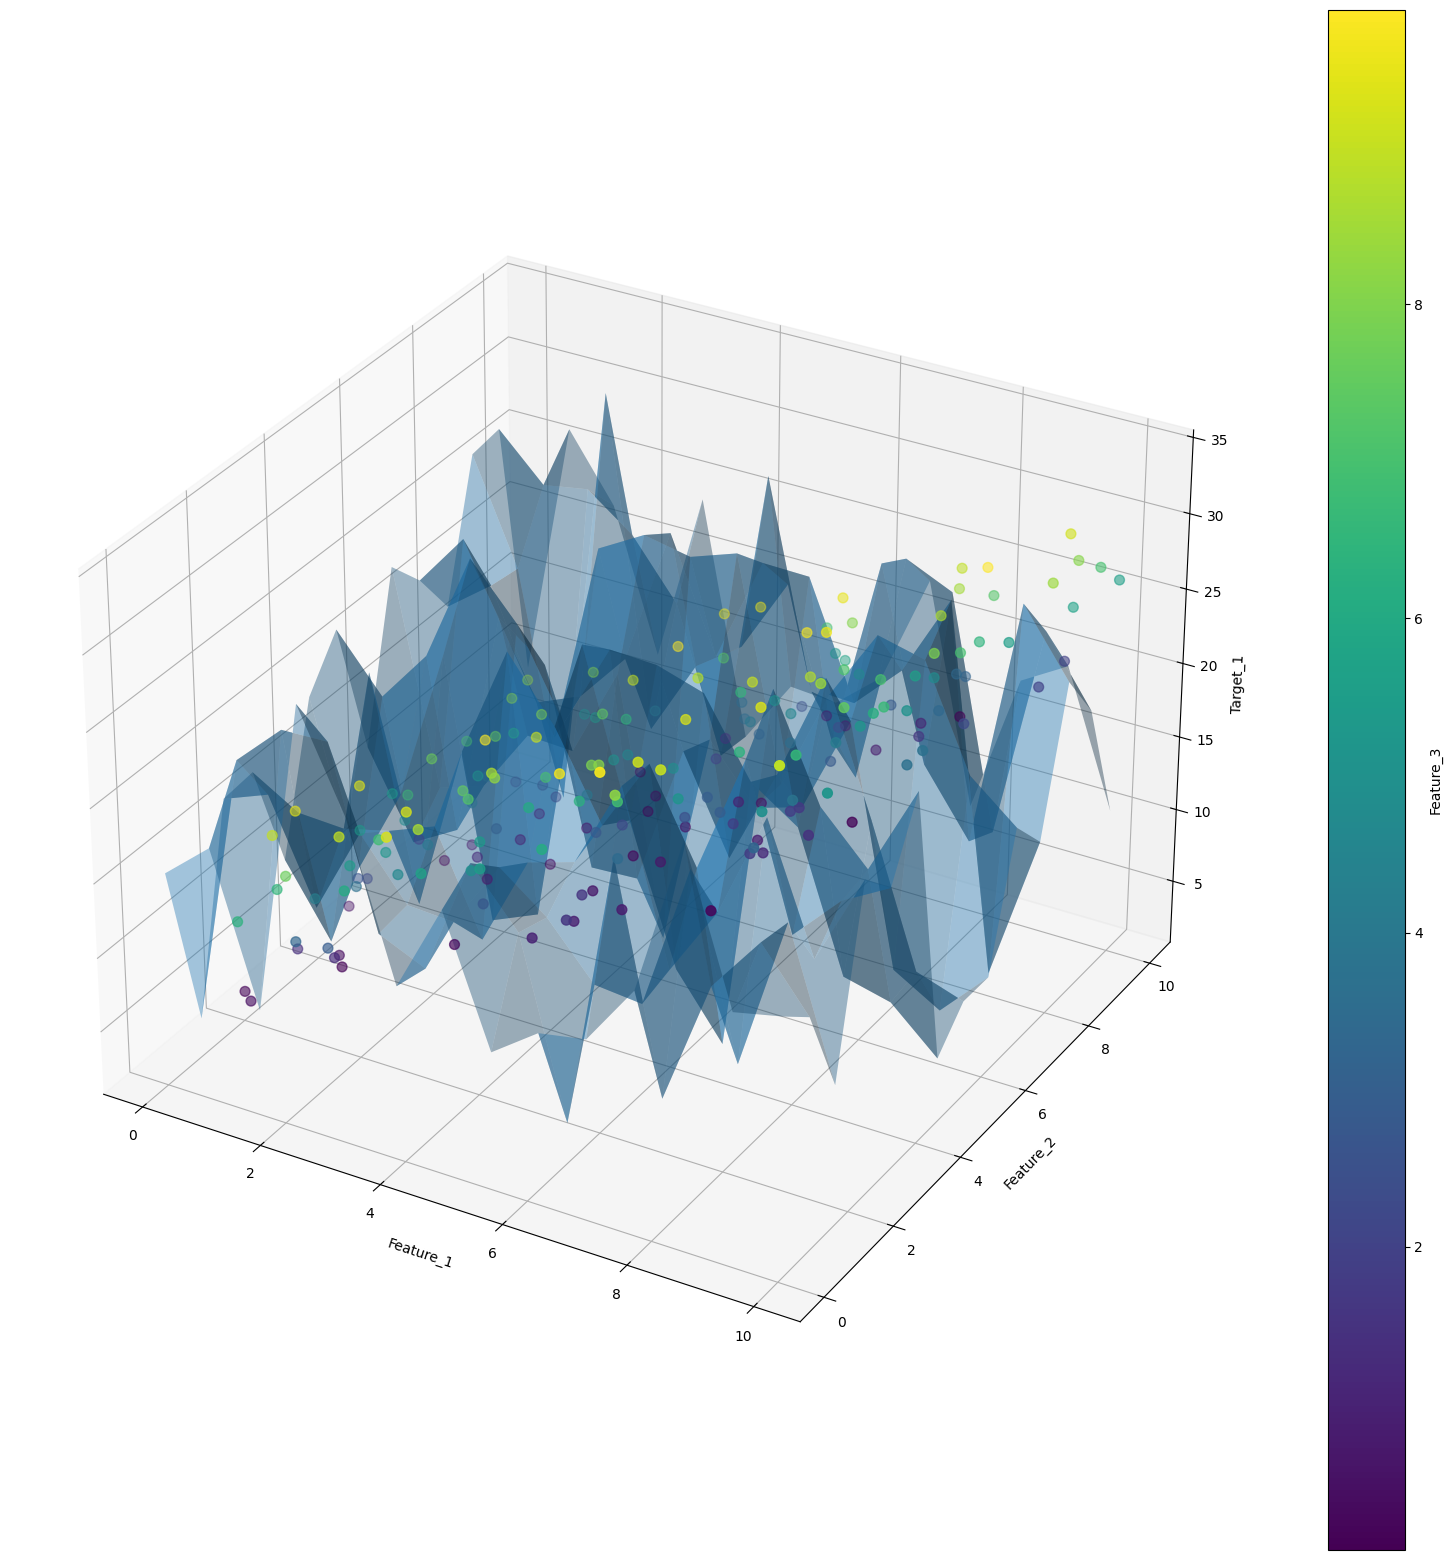

In [54]:
import matplotlib.pyplot as plt

# Pairwise plotting won't work for a three-feature LR.
# plt.scatter(x=data['Feature_1'], y= data['Target_1'])
# plt.show()

from mpl_toolkits.mplot3d import Axes3D as a3

#Make scale:
x1_scale, x2_scale = \
  np.linspace(data['Feature_1'].values.min(), data['Feature_1'].values.max(), 14), \
  np.linspace(data['Feature_2'].values.min(), data['Feature_2'].values.max(), 14)

# Not very effective, as the predicted plots need to be 2D planes
# Forcing the y_hat to be chosen as 14 x 14 = 196!
grid_x1, grid_x2 = np.meshgrid(x1_scale, x2_scale)
grid_y = Y_hat.detach()[0:196,0].reshape(grid_x1.shape)
print(grid_x1.shape)

fig = plt.figure(figsize=(20,20))
ax = fig.add_subplot(111, projection='3d')

# Scatter
scatter = ax.scatter3D(data.Feature_1, data.Feature_2, data.Target_1,
             c=data.Feature_3, cmap='viridis', s=50)

# Label the fields, Axis and ticks
ax.set_xlabel('Feature_1')
ax.set_ylabel('Feature_2')
ax.set_zlabel('Target_1')
plt.colorbar(scatter, label="Feature_3")

# Plot the Regression-Plane
ax.plot_surface(grid_x1, grid_x2, grid_y, alpha=0.4)

plt.show()